
### Autores:

- Agustin Nagy
- Leandro Saraceno
---

**Problema**

Una prepaga quiere optimizar costos decidiendo los montos que cobra mensualmente a sus socios de manera más eficaz. Para ello cuenta con una base de datos, disponible aquí, en la que se resumen algunas características de sus asociados y el monto que pagan de cuota médico/asistencial.


*   Desarrollar los algoritmos apropiados basados en los contenidos vistos en la materia para poder, a partir de los datos disponibles, construir un modelo que permita predecir el monto que debe cobrársele a la persona por su seguro médico.

*  Evaluar los resultados del algoritmo escogido, y comparar con otras soluciones posibles a través de métricas apropiadas.


* Estudiar qué características son las más relevantes al momento de determinar el valor de la cuota, para ayudar a la compañía a reconocer patrones de interés.


In [2]:
SEPARATOR: str = '=' * 100

In [1]:
!pip install ydata-profiling
!pip install wget

  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached minify_html-0.18.1-cp313-cp313-win_amd64.whl.metadata (18 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached phik-0.12.5-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached typeguard-4.5.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)


In [1]:

# importo numpy
import numpy as np
np.set_printoptions(precision=3, suppress=True) # y hago un truco para imprimir solamente 3 decimales

# importo una librería para utilizar valores aleatorios
import random
random.seed(10)
np.random.seed(10)

Obtenemos el dataset desde github

In [3]:

dataset = dict()
dataset['url'] = r'C:\Users\agust\OneDrive\Desktop\Proyecto 2027\DUIA\Modulo 2\insurance.csv'
dataset['extension'] = '.csv'


In [4]:
import pandas as pd

df = pd.read_csv(dataset['url'])
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Análisis exploratorio del Dataset


## Columnas
- **age**: edad del beneficiario principal
- **sex**: contratista de seguros género, femenino, masculino
- **bmi**: Índice de masa corporal, que proporciona una comprensión del peso corporal, que es relativamente alto o bajo en relación con la altura,
índice objetivo del peso corporal (kg/m²) que utiliza la relación entre la altura y el peso, idealmente de 18,5 a 24,9.
- **children**: Número de hijos cubiertos por el seguro médico / Número de personas a cargo
- **smoker**: fumador si o no
- **region**: la zona de residencia del beneficiario en los EE. UU., noreste, sureste, suroeste, noroeste.
- **charges**: Costos médicos individuales facturados por el seguro médico.


---


## Variable objetivo identificada
Columna: **charges**


In [5]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile

ModuleNotFoundError: No module named 'pkg_resources'

Se identifican algunas instacias duplicadas y decidimos eliminarlas

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Nuestro dataset contiene un total de 1337 observaciones. En cada observación, se tienen las siguientes features:

*   age --> cuantitativo
*   bmi --> cuantitativo
*   children --> cuantitativo
*   sex --> cualitativo
*   smoker --> cualitativo
*   region --> cualitativo

Por otro lado, nuestra variable objetivo será

*   charges -> cuantitativa

Teniendo en cuenta que la variable que se quiere predecir es una variable real continua, se plantea un problema de regresión.

**Parte I - Regresión Lineal**

Desde el análisis exploratorio de los datos, sabemos que existen features que tienen un alto índice de correlación con nuestra variable objetivo:

*   age
*   smoker

Lo que resulta bastante razonable, ya que dichas features describen el potencial estado de salud del asegurado.

Por otro lado, teniendo en cuenta que se quiere predecir una cuota de seguro médico en función de las características, tendría sentido utilizar la feature

* bmi

¿Que información potencialmente pueden aportar las demás features?.

* sex, eventualmente podría tenerse en cuenta el sexo para saber si hay alguna variación en la tarifa del seguro médico.

* region. Si se tuviera información en concreto que cierta región tiene cierta influencia en el estado de salud de los asegurados, pudiera tenerse en cuenta.

* children. La cantidad de hijos no parece tener una fuerte influencia en la tarifa del seguro médico (salvo que se quiera extender la cobertura a los hijos).


**Con todas las features**


Obtenemos los datos del data frame y la variable objetivo, para luego hacer un boxplot de la variable objetivo.

In [8]:
X_df = df.filter(['age', 'sex', 'bmi', 'children', 'smoker', 'region'])
y = df.filter(['charges'])

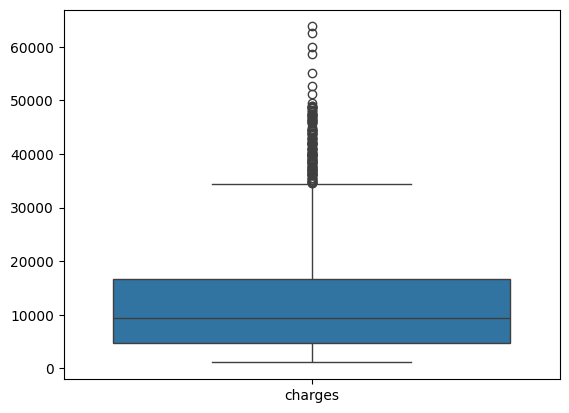

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(y)

plt.show()

Teniendo en cuenta que tenemos features categóricas (i.e. variables cualitativas), hacemos un encoder para dichas variables.

Como contrapartida, esto aumenta mucho la dimensionalidad del espacio de características.

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


Encoder = ColumnTransformer(
    transformers=[("cat",OneHotEncoder(), ["sex", "smoker", "region"])],
    remainder="passthrough",
    verbose_feature_names_out=False
    )

X = Encoder.fit_transform(X_df)

X

array([[ 1.  ,  0.  ,  0.  , ..., 19.  , 27.9 ,  0.  ],
       [ 0.  ,  1.  ,  1.  , ..., 18.  , 33.77,  1.  ],
       [ 0.  ,  1.  ,  1.  , ..., 28.  , 33.  ,  3.  ],
       ...,
       [ 1.  ,  0.  ,  1.  , ..., 18.  , 36.85,  0.  ],
       [ 1.  ,  0.  ,  1.  , ..., 21.  , 25.8 ,  0.  ],
       [ 1.  ,  0.  ,  0.  , ..., 61.  , 29.07,  0.  ]], shape=(1337, 11))

Creamos un nuevo Data Frame con las nuevas features

In [11]:
df_transformado = pd.DataFrame(X,columns=Encoder.get_feature_names_out())
new_labels = df_transformado.columns
df_transformado.head(10)

,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,age,bmi,children
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0
5,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,31.0,25.740,0.0
6,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,46.0,33.440,1.0
7,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,37.0,27.740,3.0
8,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,37.0,29.830,2.0
9,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,60.0,25.840,0.0


# Particionamiento del Dataset (Train / Val / Test)

Partición aleatoria de los datos para lograr una distribución equilibrada entre los distintos conjuntos.

* 70% de los datos se destina al entrenamiento.

  * Del conjunto de entrenamiento, se separa un 10% para validación.
* El 30% restante se destina al conjunto de prueba (test).

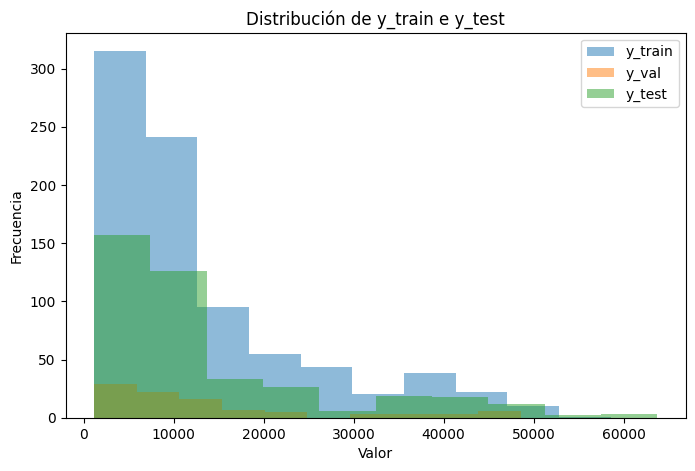

In [12]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Primera partición
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Segunda Particion (validación)
X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

plt.figure(figsize=(8,5))

plt.hist(y_train, bins=10, alpha=0.5, label='y_train')
plt.hist(y_val, bins=10, alpha=0.5, label='y_val')
plt.hist(y_test, bins=10, alpha=0.5, label='y_test')

plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Distribución de y_train e y_test')
plt.legend()

plt.show()


# Etapa 1: Entrenamiento y Selección de Modelos

Durante esta etapa se entrenaron y validaron distintos modelos de regresión con el objetivo de identificar la configuración que ofrece el mejor desempeño para la predicción del costo del seguro médico.

## Etapa 1.a: Modelos Lineales

Se implementaron y evaluaron los siguientes modelos:

- Regresión Lineal simple
- Ridge Regression
- Lasso Regression

## Etapa 1.b: Modelos No Lineales

Se implementaron y evaluaron los siguientes modelos:

- Random Forest Regressor
- XGBoost Regressor

Para cada modelo se realizó una búsqueda de hiperparámetros utilizando el conjunto de validación. Posteriormente, se seleccionó la configuración con el menor error de predicción para ser evaluada en el conjunto de prueba.

---
### Etapa 1.a: Modelos Lineales
---
**Regresión lineal simple**

En primera instancia, se entrena un modelo de regresión lineal, permitiendo el desplazamiento al hiperplano para que ajuste de mejor manera, sin ningún tipo de estandarización de los datos.

Se utilizan como métricas para evaluar los modelos el error cuadrático medio (mse) y el error absoluto medio (mae) $$mse = \frac{1}{n} \sum_{i} (y_i-\hat{y}_{i})^{2} \hspace{2cm} mae = \frac{1}{n} \sum_{i=1}^{n} \vert y_{i} - \hat{y}_{i} \vert$$

Previo a analizar los modelos, hacemos una estandarización de los datos aplicando el estandar scaler:
$$ z = \frac{x-\mu}{\sigma}$$
a las features
* bmi
* age

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


Scaler = ColumnTransformer(
    transformers=[("std",StandardScaler(), [8,9])],
    remainder="passthrough",
    verbose_feature_names_out=False
)

# escalado de los datos de entrenamiento
X_train_scaled = Scaler.fit_transform(X_train)

# escalado de los datos de validación
X_val_scaled = Scaler.fit_transform(X_val)

# escalado de los datos de test
X_test_scaled = Scaler.fit_transform(X_test)

new_labels = [
    "age",
    "bmi",
    "sex_female",
    "sex_male",
    "smoker_no",
    "smoker_yes",
    "region_northeast",
    "region_northwest",
    "region_southeast",
    "region_southwest",
    "children"
]


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


# Instanciamos el modelo y lo entrenamos

linear_regression_model = LinearRegression(fit_intercept=True)
linear_regression_model.fit(X_train, y_train)

# lo evaluamos sobre los datos de validación utilizando MSE
y_hat_val = linear_regression_model.predict(X_val)
mse = mean_squared_error(y_val, y_hat_val)
mae = mean_absolute_error(y_val, y_hat_val)

print(SEPARATOR)
print('Simple linear regression model:')
print('MSE in validation data = {:.4f}'.format(mse))
print('MAE in validation data = {:.4f}'.format(mae))



# lo evaluamos sobre los datos de test utilizando MSE

y_hat_test = linear_regression_model.predict(X_test)
mse = mean_squared_error(y_test, y_hat_test)
mae = mean_absolute_error(y_test, y_hat_test)

print(SEPARATOR)
print('Simple linear regression model:')
print('MSE in test data = {:.4f}'.format(mse))
print('MAE in test data = {:.4f}'.format(mae))
print(SEPARATOR)



Simple linear regression model:
MSE in validation data = 38693006.4498
MAE in validation data = 4258.5284
Simple linear regression model:
MSE in test data = 39434117.0299
MAE in test data = 4173.4399


 Prueba de modelo con datos estandarizados

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


# Instanciamos el modelo y lo entrenamos

linear_regression_model = LinearRegression(fit_intercept=True)
linear_regression_model.fit(X_train_scaled, y_train)

# lo evaluamos sobre los datos de validación utilizando MSE

y_hat_val = linear_regression_model.predict(X_val_scaled)
mse = mean_squared_error(y_val, y_hat_val)
mae = mean_absolute_error(y_val, y_hat_val)

print(SEPARATOR)
print('Simple linear regression model:')
print('MSE in validation data = {:.4f}'.format(mse))
print('MAE in validation data = {:.4f}'.format(mae))
print(SEPARATOR)

# lo evaluamos sobre los datos de test utilizando MSE
y_hat_test = linear_regression_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_hat_test)
mae = mean_absolute_error(y_test, y_hat_test)
print('Simple linear regression model:')
print('MSE in test data = {:.4f}'.format(mse))
print('MAE in test data = {:.4f}'.format(mae))
print(SEPARATOR)


Simple linear regression model:
MSE in validation data = 37820857.2673
MAE in validation data = 4365.6498
Simple linear regression model:
MSE in test data = 39847425.6794
MAE in test data = 4126.7100


Hacemos un scatterplot de los valores predichos vs los valores reales con regresión lineal simple

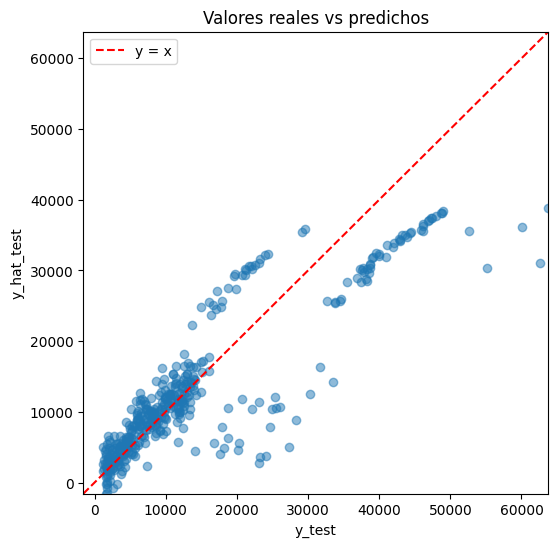

In [ ]:
import matplotlib.pyplot as plt

# Límites comunes para ambos ejes
y_test_array = y_test.squeeze()

min_val = min(y_test_array.min(), y_hat_test.min())
max_val = max(y_test_array.max(), y_hat_test.max())


plt.figure(figsize=(6,6))

plt.scatter(y_test, y_hat_test, alpha=0.5)

plt.xlabel('y_test')
plt.ylabel('y_hat_test')
plt.title('Valores reales vs predichos')

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Recta ideal y = x
plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--',
         label='y = x')

plt.legend()
plt.show()

**Ridge y LASSO**

Intentaremos mejorar el modelo de regresión lineal con los términos reguladores

$$ f_{\theta}(\mathbf{X}) = \sum_{i} \theta_{i} x_{i} + \lambda \Omega(\theta) $$
Donde  
* $\Omega(\theta) = \lvert \lvert \theta \rvert \rvert_{1}$ -> LASSO
* $\Omega(\theta) = \lvert \lvert \theta \rvert \rvert_{2}$ -> Ridge

Con diferentes valores de $\lambda$ se observa que aumenta MSE

En la siguiente celda, instanciamos, entrenamos y evaluamos modelos LASSO y Ridge simultáneamente. Asimismo, comparamos los errores mse y mae sobre los datos test para saber cuál ajusta mejor.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

print('Model selection Ridge y LASSO')

# valores de alpha que vamos a evaluar

alpha_values = [0.0001, 1.0, 10.0, 100.0, 10000,100000]
ridge_models = []

# se crean los arreglos para guardar los mse y mae para ridge
mse_ridge_regression = np.zeros(len(alpha_values))
mae_ridge_regression = np.zeros(len(alpha_values))


# se crean los arreglos para guardar los mse y mae para LASSO
mse_lasso_regression = np.zeros(len(alpha_values))
mae_lasso_regression = np.zeros(len(alpha_values))


print(SEPARATOR)
print('Ridge regression')
print(SEPARATOR)

# Se instancian y se entrenan los modelos ridge para cada valor de alpha

i = 0
for alpha in alpha_values:
  ridge_model = Ridge(alpha=alpha, fit_intercept=True)
  ridge_model.fit(X_train_scaled, y_train)
  ridge_models.append(ridge_model)

# Para los modelos Ridge hacemos model selection sobre los datos de validación

for i in range(len(ridge_models)):
  y_hat_val = ridge_models[i].predict(X_val_scaled)
  current_mse = mean_squared_error(y_val, y_hat_val)
  current_mae = mean_absolute_error(y_val, y_hat_val)
  mse_ridge_regression[i] = current_mse
  mae_ridge_regression[i] = current_mae
  print('Ridge with alpha: {:.4f} \t MSE = {:.4f}'.format(alpha_values[i], current_mse))
  print('Ridge with alpha: {:.4f} \t MAE = {:.4f}'.format(alpha_values[i], current_mae))

# identificamos el valor de alpha que nos da mejores resultados
best_alpha_ridge_idx = np.argmin(mse_ridge_regression)
best_alpha_ridge = alpha_values[best_alpha_ridge_idx]
best_mse_ridge = mse_ridge_regression[best_alpha_ridge_idx]
best_mae_ridge = mae_ridge_regression[best_alpha_ridge_idx]
best_ridge_model = ridge_models[best_alpha_ridge_idx]
print(SEPARATOR)
print('Best Ridge regression model in the validation set: alpha={:.4f} \t MSE={:.4f}'.format(best_alpha_ridge, best_mse_ridge))
print('Best Ridge regression model in the validation set: alpha={:.4f} \t MAE={:.4f}'.format(best_alpha_ridge, best_mae_ridge))
print(SEPARATOR)

print('\n\n')

print(SEPARATOR)
print("LASSO regression")
print(SEPARATOR)

lasso_models = []
i=0
for alpha in alpha_values:
  lasso_model = Lasso(alpha=alpha, fit_intercept=True)
  lasso_models.append(lasso_model)
  lasso_model.fit(X_val_scaled, y_val)
  # y lo evaluamos sobre los datos de validation
  y_hat_val = lasso_model.predict(X_val_scaled)
  current_mse = mean_squared_error(y_val, y_hat_val)
  current_mae = mean_absolute_error(y_val, y_hat_val)
  mse_lasso_regression[i] = current_mse
  mae_lasso_regression[i] = current_mae
  print('LASSO with alpha: {:.4f} \t MSE = {:.4f}'.format(alpha_values[i], current_mse))
  print('LASSO with alpha: {:.4f} \t MAE = {:.4f}'.format(alpha_values[i], current_mae))
  i = i+1

# identificamos el valor de alpha que nos da mejores resultados
best_alpha_lasso_idx = np.argmin(mse_lasso_regression)
best_alpha_lasso = alpha_values[best_alpha_lasso_idx]
best_mae_lasso = mae_lasso_regression[best_alpha_lasso_idx]
best_mse_lasso = mse_lasso_regression[best_alpha_lasso_idx]
best_lasso_model = lasso_models[best_alpha_lasso_idx]
print(SEPARATOR)
print('Best LASSO regression model in the validation set: alpha={:.4f} \t MSE={:.4f}'.format(best_alpha_lasso, best_mse_lasso))
print('Best LASSO regression model in the validation set: alpha={:.4f} \t MAE={:.4f}'.format(best_alpha_lasso, best_mae_lasso))
print(SEPARATOR)


Model selection Ridge y LASSO
Ridge regression
Ridge with alpha: 0.0001 	 MSE = 37820864.5187
Ridge with alpha: 0.0001 	 MAE = 4365.6509
Ridge with alpha: 1.0000 	 MSE = 37894374.7899
Ridge with alpha: 1.0000 	 MAE = 4377.0682
Ridge with alpha: 10.0000 	 MSE = 38639239.0724
Ridge with alpha: 10.0000 	 MAE = 4476.7357
Ridge with alpha: 100.0000 	 MSE = 49970428.4365
Ridge with alpha: 100.0000 	 MAE = 5290.2294
Ridge with alpha: 10000.0000 	 MSE = 159633176.5462
Ridge with alpha: 10000.0000 	 MAE = 9339.7627
Ridge with alpha: 100000.0000 	 MSE = 166975087.5309
Ridge with alpha: 100000.0000 	 MAE = 9540.8894
Best Ridge regression model in the validation set: alpha=0.0001 	 MSE=37820864.5187
Best Ridge regression model in the validation set: alpha=0.0001 	 MAE=4365.6509



LASSO regression
LASSO with alpha: 0.0001 	 MSE = 34452260.6733
LASSO with alpha: 0.0001 	 MAE = 4130.6937
LASSO with alpha: 1.0000 	 MSE = 34452292.0864
LASSO with alpha: 1.0000 	 MAE = 4131.2748
LASSO with alpha: 10.00

Como conclusión, el modelo de regresión lineal parece no ser adecuado, ya que tanto la regresión lineal usual como los modelos LASSO y Ridge, no parecen tener un buen ajuste.

Una de las cosas que será interesante evaluar, es si al haber tomado todas las variables, hemos agregado mucho ruido al modelo (maldicion de dimensionalidad). Para esto, hacemos feature selection con LASSO y observamos cuáles de las features son más relevantes.

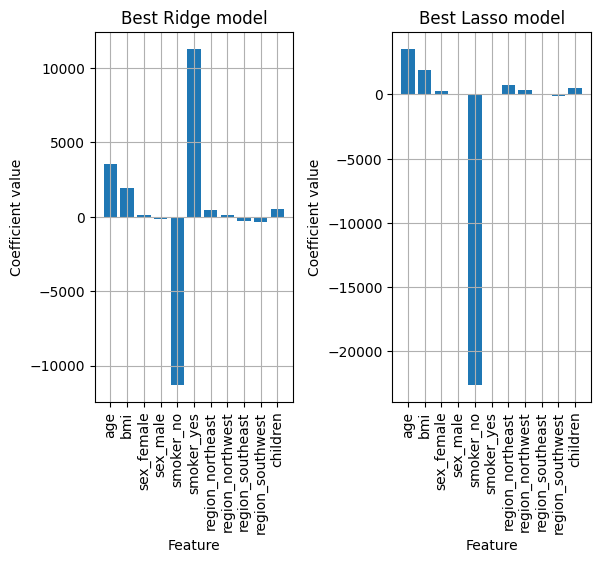

In [21]:

models = [best_ridge_model, # Ridge Regression
          best_lasso_model] # Lasso
model_names = ['Best Ridge model', 'Best Lasso model']

# inicializamos los gráficos
fig, axes = plt.subplots(1, len(models))
plt.subplots_adjust(wspace=0.5)
# y entrenamos los modelos
i=0
for model in models:
  model.fit(X_train_scaled, y_train)
  # sacamos los coeficientes
  theta=model.coef_
  # mostramos graficamente los pesos
  axes[i].bar(np.arange(np.squeeze(theta.size)), np.squeeze(theta))
  axes[i].set_title(model_names[i])
  axes[i].set_xlabel('Feature')
  axes[i].set_ylabel('Coefficient value')
  axes[i].set_xticks(np.arange(theta.size))
  axes[i].set_xticklabels(labels=new_labels,rotation = 90)
  axes[i].grid(True)
  i = i+1
plt.show()


Se puede hacer un análisis muy interesante para hacer un feature selection que me ayude a mejorar el modelo. En particular, se puede ver que las features que tienen mayor peso para una regresión lineal son

* smoke
* bmi
* edad
* sex (solo femenino, se puede eliminar masculino)
* region (solo región norte, se puede descartar sur)
* children


**Evaluación final de regresión utilizando modelos lineales**

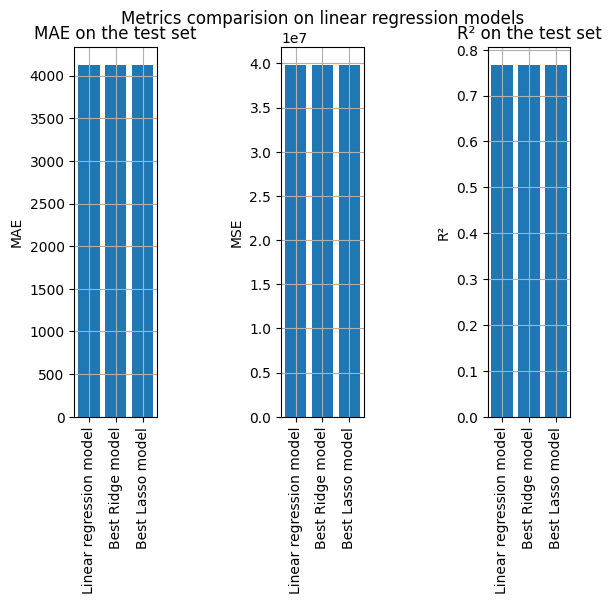

In [22]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Utilizamos los datos test para evaluar los mejores modelos obtenidos

models = [linear_regression_model,
          best_ridge_model, # Ridge Regression
          best_lasso_model] # Lasso
model_names = ['Linear regression model','Best Ridge model', 'Best Lasso model']

mse=[]
mae=[]
r2=[]

i=0
for model in models:
  # evaluamos los modelos
  y_hat_test = model.predict(X_test_scaled)
  #calculamos los errores
  current_mse = mean_squared_error(y_test,y_hat_test)
  current_mae = mean_absolute_error(y_test,y_hat_test)
  current_r2 = r2_score(y_test,y_hat_test)
  mse.append(current_mse)
  mae.append(current_mae)
  r2.append(current_r2)
  i = i+1

# generamos graficas comparando los valores de MAE, MSE y R2
fig, axes = plt.subplots(1, 3)
plt.subplots_adjust(wspace=1.5)
# MAE
axes[0].bar(np.arange(len(models)), current_mae)
axes[0].set_title('MAE on the test set')
axes[0].set_ylabel('MAE')
axes[0].set_xticks(np.arange(len(model_names)))
axes[0].set_xticklabels(labels=model_names, rotation=90)
axes[0].grid(True)
# MSE
axes[1].bar(np.arange(len(models)), current_mse)
axes[1].set_title('Metrics comparision on linear regression models')
axes[1].set_ylabel('MSE')
axes[1].set_xticks(np.arange(len(model_names)))
axes[1].set_xticklabels(labels=model_names, rotation=90)
axes[1].grid(True)
# R2
axes[2].bar(np.arange(len(models)), current_r2)
axes[2].set_title('R² on the test set')
axes[2].set_ylabel('R²')
axes[2].set_xticks(np.arange(len(model_names)))
axes[2].set_xticklabels(labels=model_names, rotation=90)
axes[2].grid(True)

plt.show()



# Etapa 1.b: Modelos No Lineales

### Random Forest Regressor

Con el objetivo de identificar la configuración óptima del modelo, se realizará una búsqueda sobre diferentes cantidades de árboles: **25, 50, 75, 100, 200, 400, 1000 y 2000**.

Para cada configuración, el modelo será entrenado con el conjunto de entrenamiento y evaluado sobre el conjunto de validación mediante el cálculo del **Mean Squared Error (MSE)**. La configuración seleccionada será aquella que presente el menor MSE, ya que representa el mejor desempeño predictivo sobre datos no utilizados durante el entrenamiento.

Random Forest Regression
N = 25 - MSE = 23134353.4040 - Train time = 0.0772 s - Pred time = 0.0022 s
N = 50 - MSE = 23271752.9913 - Train time = 0.1374 s - Pred time = 0.0039 s
N = 75 - MSE = 24190962.0913 - Train time = 0.2104 s - Pred time = 0.0056 s
N = 100 - MSE = 23797147.4327 - Train time = 0.2742 s - Pred time = 0.0086 s
N = 200 - MSE = 24072609.7167 - Train time = 0.5345 s - Pred time = 0.0210 s
N = 400 - MSE = 24060382.7994 - Train time = 1.0986 s - Pred time = 0.0378 s
N = 1000 - MSE = 24108796.9014 - Train time = 2.8124 s - Pred time = 0.0817 s
N = 2000 - MSE = 24177898.1092 - Train time = 6.0536 s - Pred time = 0.1684 s


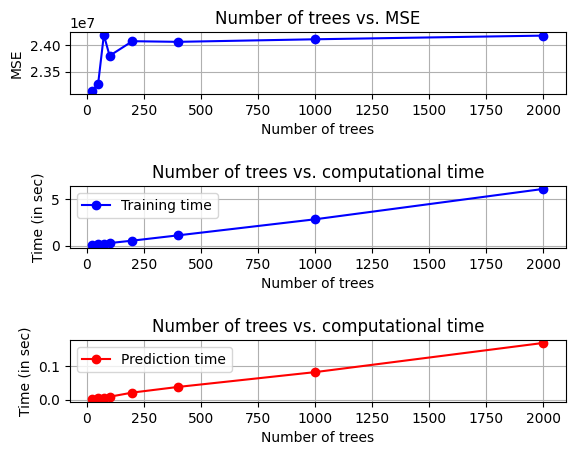

In [23]:
from sklearn.ensemble import RandomForestRegressor
import time

# numero de arboles
num_trees = [25, 50, 75, 100, 200, 400, 1000, 2000]
# tiempos de entrenamiento y prediccion
training_time = np.zeros(len(num_trees))
prediction_time = np.zeros(len(num_trees))
# inicializamos una lista de modelos
rf_models = []

# arreglo para ir guardando los valores de MSE
mse_rf_regression = np.zeros(len(num_trees))

# iteramos por cada numero de arboles
i = 0
print('Random Forest Regression')
print(SEPARATOR)
for N in num_trees:
  # definimos el modelo
  model = RandomForestRegressor(n_estimators=N, random_state=10)
  # lo entrenamos sobre los datos de entrenamiento, midiendo el tiempo que lleva
  start_time = time.time()
  model.fit(X_train_scaled, np.squeeze(y_train))
  training_time[i] = time.time() - start_time
  rf_models.append(model)
  # predecimos sobre los datos de validación, registrando el tiempo que lleva
  start_time = time.time()
  y_hat_val = model.predict(X_val_scaled)
  prediction_time[i] = time.time() - start_time
  # evaluamos el MSE
  mse_rf_regression[i] = mean_squared_error(y_val, y_hat_val)
  # imprimimos las estadisticas
  print('N = {} - MSE = {:.4f} - Train time = {:.4f} s - Pred time = {:.4f} s'.format(N, mse_rf_regression[i], training_time[i], prediction_time[i]))
  i = i+1
print(SEPARATOR)

# inicializamos los gráficos
fig, axes = plt.subplots(3, 1)
plt.subplots_adjust(hspace=1.5)
# mostramos graficamente la evolución del MSE
axes[0].plot(np.asarray(num_trees), mse_rf_regression, '-bo')
axes[0].set_title('Number of trees vs. MSE')
axes[0].set_xlabel('Number of trees')
axes[0].set_ylabel('MSE')
axes[0].grid(True)
# y el tiempo en entrenamiento
axes[1].plot(np.asarray(num_trees), training_time, '-bo')
axes[1].legend(['Training time'])
axes[1].set_title('Number of trees vs. computational time')
axes[1].set_xlabel('Number of trees')
axes[1].set_ylabel('Time (in sec)')
axes[1].grid(True)
# y en validacion
axes[2].plot(np.asarray(num_trees), prediction_time, '-ro')
axes[2].legend(['Prediction time'])
axes[2].set_title('Number of trees vs. computational time')
axes[2].set_xlabel('Number of trees')
axes[2].set_ylabel('Time (in sec)')
axes[2].grid(True)
plt.show()

Luego de probar con las siguientes variantes en cantidad de arboles:
-  25, 50, 75, 100, 200, 400, 1000, 2000

Ientificamos que el Random Forest con una configuracion de 25 arboles presenta un Error Minimo Cuatratico inferior al resto de las configuraciones. Identificamos que el costo computacional epieza a ser notable con la configuracion de 100 arboles.

In [24]:
# identificamos el mejor modelo
best_n_rf_idx = np.argmin(mse_rf_regression)
best_n_rf = num_trees[best_n_rf_idx]
best_mse_rf = mse_rf_regression[best_n_rf_idx]
best_rf_model = rf_models[best_n_rf_idx]

print(SEPARATOR)
print('Best RF regression model in the validation set: \t T={} \t\t MSE={:.4f}'.format(best_n_rf, best_mse_rf))

Best RF regression model in the validation set: 	 T=25 		 MSE=23134353.4040


### XGBoost Regressor

Se evaluarán diferentes configuraciones del modelo **XGBoost Regressor**, variando los hiperparámetros **n_estimators**, **learning_rate** y **max_depth**. Para ello se utilizará una búsqueda exhaustiva mediante **GridSearchCV**, explorando todas las combinaciones posibles de los valores definidos para cada parámetro.

Cada configuración será entrenada utilizando el conjunto de entrenamiento y evaluada sobre el conjunto de validación. Como criterio de selección se utilizará el **Error Cuadrático Medio (MSE)**, eligiendo finalmente la combinación de hiperparámetros que obtenga el menor valor de esta métrica.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import mean_squared_error


print(SEPARATOR)
print('XGBoost Regression')
print(SEPARATOR)

# Definimos el espacio de búsqueda de hiperparámetros:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}

# Inicializamos el modelo para hacer el entrenamiento
xgbr = xgb.XGBRegressor(
    objective='reg:squarederror',  # pérdida = MSE “clásico”
    eval_metric='rmse',
    random_state=10
)

# Preparamos un split CV para usar nuestro conjunto de validación

# primero apilamos las matrices de entrenamiento y validación
X_cv = np.vstack([X_train_scaled,X_val_scaled])
# y hacemos lo mismo con las predicciones
y_cv = np.vstack([y_train, y_val])

# Vector con -1 para filas de entrenamiento y 0 para validación
test_fold = np.concatenate([
    -np.ones(len(X_train_scaled)),
     np.zeros(len(X_val_scaled))
])
cv = PredefinedSplit(test_fold)

# Ahora configuramos el grid search para que se haga usando nuestra partición predefinida
grid_search = GridSearchCV(
    estimator=xgbr,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    refit=False
)

# Ajustamos el grid search, imprimimos los mejores hiperparámetros y mostramos la perfo que obtuvimos
grid_search.fit(X_cv, y_cv)
print(SEPARATOR)
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
best_mse_val_grid = -grid_search.best_score_
print(f"Mejor MSE (val) según GridSearch: {best_mse_val_grid:.4f}")

# Reentrenamos el mejor modelo pasando los mejores parámetros
best_xgbr = xgb.XGBRegressor(
    **grid_search.best_params_,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=10
)
best_xgbr.fit(X_train_scaled, y_train)

# Evaluamos el modelo final sobre los datos de validación, para ver si dio igual
y_hat_val_xgb = best_xgbr.predict(X_val_scaled)
mse_val_xgb   = mean_squared_error(y_val, y_hat_val_xgb)
print(f"MSE del mejor XGBoost en validación: {mse_val_xgb:.4f}")


XGBoost Regression
Fitting 1 folds for each of 36 candidates, totalling 36 fits
Mejores hiperparámetros encontrados:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Mejor MSE (val) según GridSearch: 21565883.3317
MSE del mejor XGBoost en validación: 21565882.0000


## Features importance Random Forest vs XGBoost

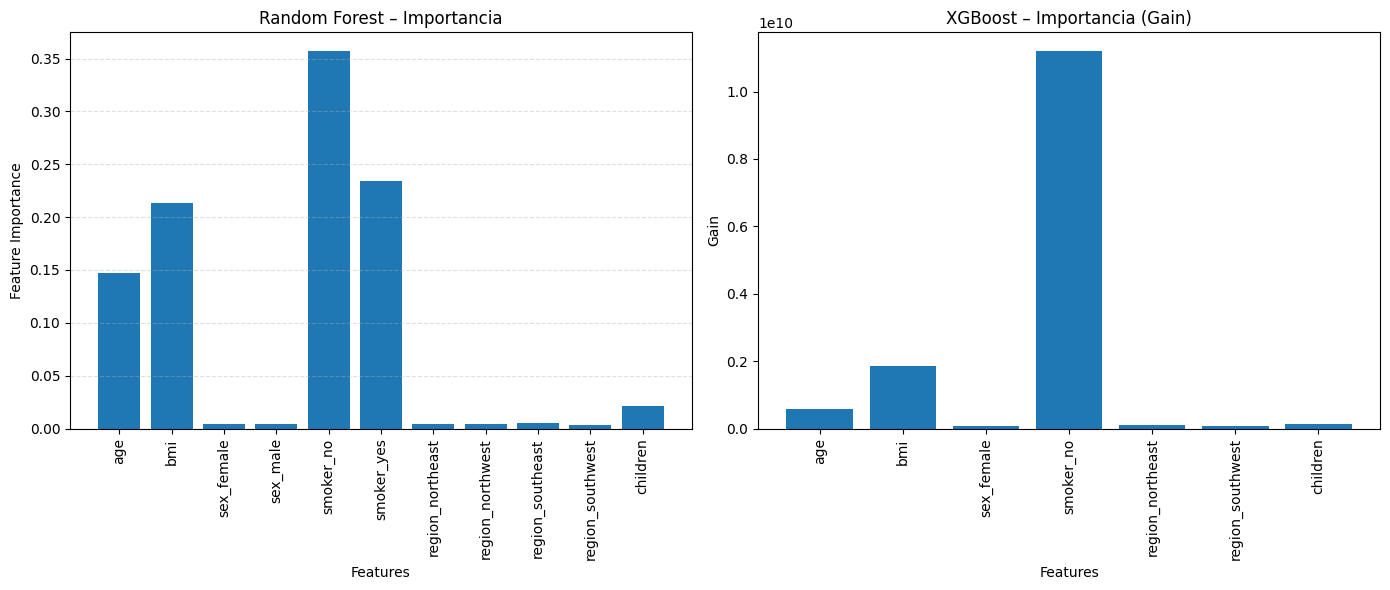

In [27]:
booster = best_xgbr.get_booster()
feature_importances = booster.get_score(importance_type='gain')

# Mapeamos f0, f1, … a cada nombre real, aprovechando que los tenemos en el dataset
feature_map = {f'f{i}': name for i, name in enumerate(new_labels)}
mapped_importances = {
    feature_map.get(k, k): v for k, v in feature_importances.items()
}
sorted_items = mapped_importances.items()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

n_feats = len(new_labels)
axes[0].bar(np.arange(n_feats), best_rf_model.feature_importances_)
axes[0].set_xticks(np.arange(n_feats))
axes[0].set_xticklabels(new_labels, rotation=90)
axes[0].set_title('Random Forest – Importancia')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Feature Importance')
axes[0].grid(True, axis='y', ls='--', alpha=0.4)

axes[1].bar(*zip(*sorted_items))
axes[1].set_title('XGBoost – Importancia (Gain)')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Gain')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()



# Análisis de importancia de variables

Tanto **Random Forest** como **XGBoost** identifican al hábito de fumar como la variable más importante  para predecir el costo del seguro médico. En ambos modelos, `BMI` y `age` también presentan una influencia significativa.

La principal diferencia es que **XGBoost** le da más importancia en la variable `smoker`, mientras que **Random Forest** distribuye la importancia de forma más equilibrada entre smoker, `BMI` y `age`.

Es importante destacar que **XGBoost** ignora `smoker_yes` y se queda con `smoker_no`, ya que ambas variables representan la misma información debido al proceso de **One-Hot Encoding**.

Por otro lado, variables como **sexo**, **región** y **cantidad de hijos a cargo** presentan una importancia muy baja, indicando que tienen poca influencia en las predicciones del modelo.

# Etapa 2: Predicción y Evaluación Final

Una vez finalizado el proceso de entrenamiento y selección de hiperparámetros, se procede a evaluar el rendimiento de cada modelo utilizando el conjunto de **test**, el cual no fue empleado durante las etapas de entrenamiento ni validación.

Para comparar el desempeño de los distintos modelos se calculan las siguientes métricas:

- **MAE (Mean Absolute Error)**
- **MSE (Mean Squared Error)**
- **R² (Coeficiente de Determinación)**

## Modelos evaluados

1. Modelos lineales:
   - Ridge Regression
   - Lasso Regression
2. Modelos No lineales:
   - Random Forest Regressor
   - XGBoost Regressor

Predicciones Ridge


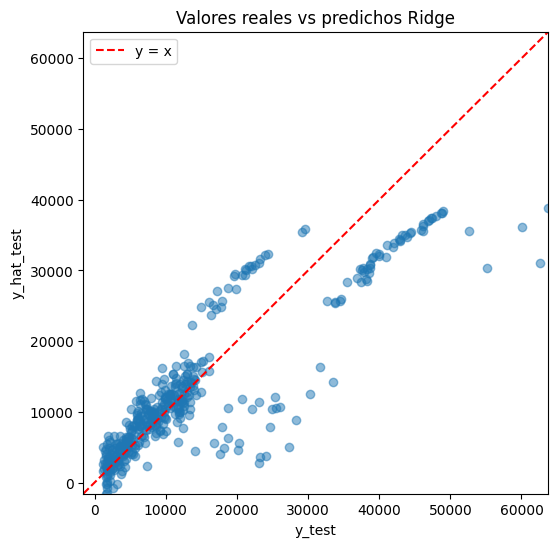

Predicciones LASSO


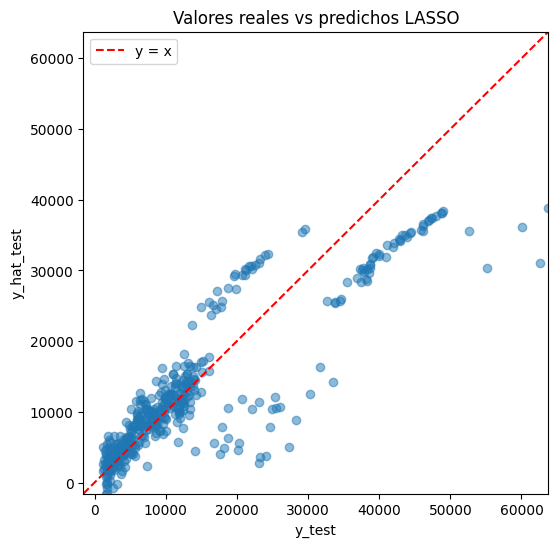

Predicciones Random Forest


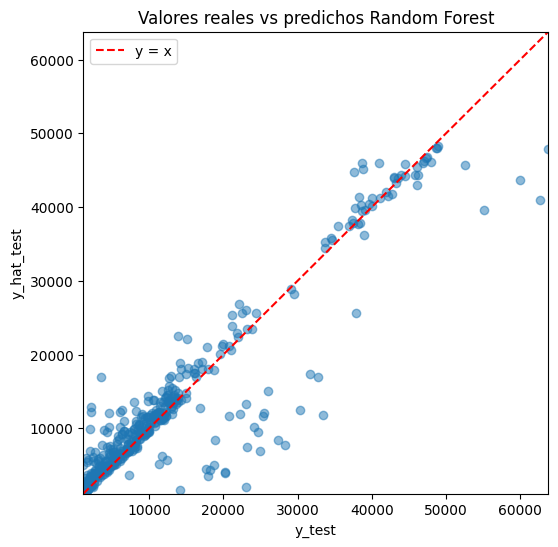

Predicciones XGBoost


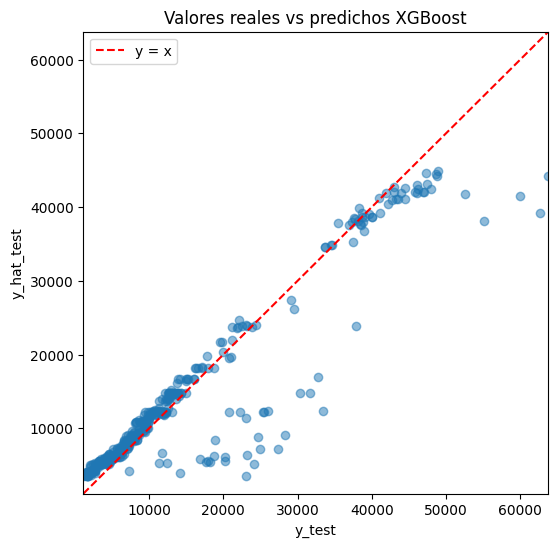

Mean Absolute Error
--> Ridge 	 MAE = 4126.7107
--> LASSO 	 MAE = 4126.7100
--> Random Forest 	 MAE = 2543.9538
--> XGBoost 	 MAE = 2588.6934
Mean Squared Error
--> Ridge 	 MSE = 39847435.8169
--> LASSO 	 MSE = 39847426.7876
--> Random Forest 	 MSE = 23051931.9906
--> XGBoost 	 MSE = 22080752.0000
R2
--> Ridge 	 R2 = 0.7671
--> LASSO 	 R2 = 0.7671
--> Random Forest 	 R2 = 0.8653
--> XGBoost 	 R2 = 0.8710


In [28]:
from sklearn.metrics import mean_absolute_error

# juntamos todos los modelos en una única lista
models_for_evaluation = [best_ridge_model, best_lasso_model, best_rf_model, best_xgbr]
model_tags = ['Ridge', 'LASSO', 'Random Forest', 'XGBoost']
# inicializamos los arreglos donde vamos a ir guardando los valores a comparar
mae_test = np.zeros(len(models_for_evaluation))
mse_test = np.zeros(len(models_for_evaluation))
r2_test = np.zeros(len(models_for_evaluation))
differences_in_prediction = []

# iteramos por cada modelo
for i in range(len(models_for_evaluation)):
  # generamos las predicciones con el método
  y_hat_test = models_for_evaluation[i].predict(X_test_scaled)
  # evaluamos en términos de MAE
  mae_test[i] = mean_absolute_error(y_test, y_hat_test)
  # evaluamos en términos de MSE
  mse_test[i] = mean_squared_error(y_test, y_hat_test)
  # podemos también calcular el R2 sobre los datos de test
  r2_test[i] = models_for_evaluation[i].score(X_test_scaled, y_test)
  # y finalmente sacar las diferencias respecto a los valores que correspondian
  current_differences = np.absolute(np.squeeze(y_test) - np.squeeze(y_hat_test))
  differences_in_prediction.append(current_differences)

  # generamos gafico por cada modelo evaluado
  print(SEPARATOR)
  print('Predicciones '+ model_tags[i])
  print(SEPARATOR)
  y_test_array_scaled = y_test.squeeze()

  min_val = min(y_test_array_scaled.min(), y_hat_test.min())
  max_val = max(y_test_array_scaled.max(), y_hat_test.max())
  plt.figure(figsize=(6,6))

  plt.scatter(y_test, y_hat_test, alpha=0.5)

  plt.xlabel('y_test')
  plt.ylabel('y_hat_test')
  plt.title('Valores reales vs predichos ' + model_tags[i])

  plt.xlim(min_val, max_val)
  plt.ylim(min_val, max_val)

  # Recta ideal y = x
  plt.plot([min_val, max_val],
          [min_val, max_val],
          'r--',
          label='y = x')

  plt.legend()
  plt.show()


print(SEPARATOR)
print('Mean Absolute Error')
print(SEPARATOR)
for i in range(len(model_tags)):
  print('--> {} \t MAE = {:.4f}'.format(model_tags[i], mae_test[i]))
print(SEPARATOR)

print('Mean Squared Error')
print(SEPARATOR)
for i in range(len(model_tags)):
  print('--> {} \t MSE = {:.4f}'.format(model_tags[i], mse_test[i]))
print(SEPARATOR)

print('R2')
print(SEPARATOR)
for i in range(len(model_tags)):
  print('--> {} \t R2 = {:.4f}'.format(model_tags[i], r2_test[i]))
print(SEPARATOR)

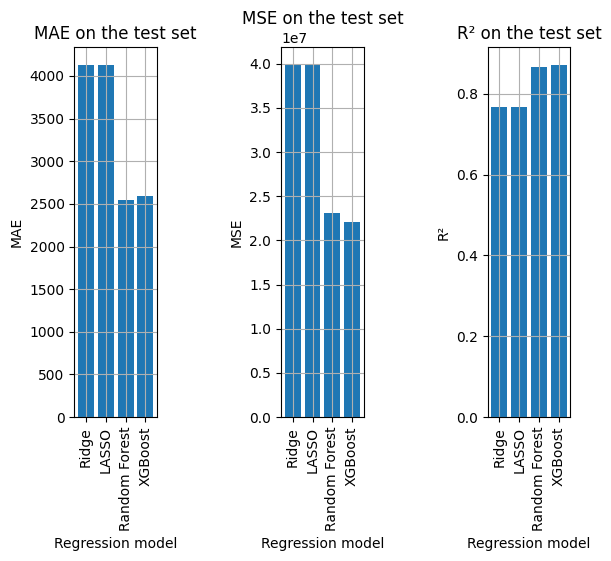

In [29]:
# generamos graficas comparando los valores de MAE, MSE y R2
fig, axes = plt.subplots(1, 3)
plt.subplots_adjust(wspace=1.5)
# MAE
axes[0].bar(np.arange(len(models_for_evaluation)), mae_test)
axes[0].set_title('MAE on the test set')
axes[0].set_xlabel('Regression model')
axes[0].set_ylabel('MAE')
axes[0].set_xticks(np.arange(len(model_tags)))
axes[0].set_xticklabels(labels=model_tags, rotation=90)
axes[0].grid(True)
# MSE
axes[1].bar(np.arange(len(models_for_evaluation)), mse_test)
axes[1].set_title('MSE on the test set')
axes[1].set_xlabel('Regression model')
axes[1].set_ylabel('MSE')
axes[1].set_xticks(np.arange(len(model_tags)))
axes[1].set_xticklabels(labels=model_tags, rotation=90)
axes[1].grid(True)
# R2
axes[2].bar(np.arange(len(models_for_evaluation)), r2_test)
axes[2].set_title('R² on the test set')
axes[2].set_xlabel('Regression model')
axes[2].set_ylabel('R²')
axes[2].set_xticks(np.arange(len(model_tags)))
axes[2].set_xticklabels(labels=model_tags, rotation=90)
axes[2].grid(True)

plt.show()

# Conclusión

A partir de las métricas obtenidas sobre el conjunto de prueba, se observa que los modelos **no lineales** presentan un desempeño superior respecto de los modelos de **regresión lineal**.

Entre los modelos evaluados, **XGBoost** obtuvo los mejores resultados, alcanzando el menor error absoluto medio (**MAE = 2590.4299**), el menor error cuadrático medio (**MSE = 22088442**) y el mayor coeficiente de determinación (**R² = 0.8709**).

Si dejar de lado a **Random Forest** que también mostró un rendimiento destacado (**R² = 0.8651**), aunque inferior al de **XGBoost**. Ambos modelos superaron de manera significativa a **Ridge** y **LASSO**.
